In [563]:
# read in dataset
!curl -L -O https://github.com/mosesyhc/de300-2026sp/raw/refs/heads/main/homework/T_F41SCHEDULE_B43_with_missing.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1577k  100 1577k    0     0  1321k      0  0:00:01  0:00:01 --:--:-- 2598k


In [588]:
import pandas as pd
inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')

/var/folders/82/knv6ptsj1ysgdp6n2mpwwn5m0000gn/T/ipykernel_97676/214319915.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')


## 1. Investigate missing data:

In [589]:
print(inventory.columns)

Index(['YEAR', 'CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR',
       'UNIQUE_CARRIER_NAME', 'SERIAL_NUMBER', 'TAIL_NUMBER',
       'AIRCRAFT_STATUS', 'OPERATING_STATUS', 'NUMBER_OF_SEATS',
       'MANUFACTURER', 'AIRCRAFT_TYPE', 'MODEL', 'CAPACITY_IN_POUNDS',
       'ACQUISITION_DATE', 'AIRLINE_ID', 'UNIQUE_CARRIER'],
      dtype='object')


In [590]:
# investigate missing data
# Columns for investigation: CARRIER, CARRIER_NAME, MANUFACTURE_YEAR, NUMBER_OF_SEATS, CAPACITY_IN_POUNDS, and AIRLINE_ID.
# For example, watch out for “North American Airlines” aircrafts. Are the CARRIER/UNIQUE_CARRIER column really missing?
# For CAPACITY_IN_POUNDS and NUMBER_OF_SEATS, identify the category of missingness. Justify your reasoning, and provide a possible imputation method.

# look at missing values in columns for investigation
missing_data = inventory[['CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR', 'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS', 'AIRLINE_ID']].isnull().sum()
missing_data

CARRIER                  49
CARRIER_NAME            105
MANUFACTURE_YEAR          3
NUMBER_OF_SEATS       13238
CAPACITY_IN_POUNDS    13332
AIRLINE_ID              105
dtype: int64

In [615]:
inventory[['CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR', 'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS', 'AIRLINE_ID']].head()

,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,NUMBER_OF_SEATS,CAPACITY_IN_POUNDS,AIRLINE_ID
0,16,PSA Airlines Inc.,2003.0,50.0,47000.0,20397.0
1,16,PSA Airlines Inc.,2003.0,50.0,47000.0,20397.0
2,16,PSA Airlines Inc.,2003.0,50.0,47000.0,20397.0
3,16,PSA Airlines Inc.,2003.0,50.0,47000.0,20397.0
4,16,PSA Airlines Inc.,2003.0,50.0,47000.0,20397.0


Fixing North American Airlines:

In [616]:
# look at north american airlines aircrafts with missing carrier/unique carrier columns
north_american_airlines = inventory[(inventory['CARRIER_NAME'] == 'North American Airlines') & (inventory['UNIQUE_CARRIER_NAME'] == 'North American Airlines') & (inventory['CARRIER'].notna())]
north_american_airlines.head(20)



,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER,MISSING_CAPACITY_IN_POUNDS,MISSING_NUMBER_OF_SEATS
11776,2007,NA,North American Airlines,1993.0,North American Airlines,26257.0,N760NA,B,Y,NaN,BOEING,NaN,B767-3,104476.0,3/23/2004 12:00:00 AM,20415.0,NaN,0,1
11777,2007,NA,North American Airlines,1995.0,North American Airlines,26277.0,N750NA,B,Y,NaN,BOEING,NaN,B757-2,58491.0,1/27/1995 12:00:00 AM,20415.0,NaN,0,1
11778,2007,NA,North American Airlines,1996.0,North American Airlines,28039.0,N769NA,B,Y,NaN,BOEING,NaN,B767-3,100500.0,2/19/2007 12:00:00 AM,20415.0,NaN,0,1
11779,2007,NA,North American Airlines,1996.0,North American Airlines,28098.0,N765NA,B,Y,NaN,BOEING,NaN,B767-3,94523.0,3/23/2006 12:00:00 AM,20415.0,NaN,0,1
11780,2007,NA,North American Airlines,1997.0,North American Airlines,28174.0,N752NA,B,Y,NaN,BOEING,NaN,B757-2,58948.0,5/12/1999 12:00:00 AM,20415.0,NaN,0,1
11781,2007,NA,North American Airlines,2000.0,North American Airlines,30043.0,N755NA,B,Y,NaN,BOEING,NaN,B757-2,56526.0,2/25/2003 12:00:00 AM,20415.0,NaN,0,1
11782,2007,NA,North American Airlines,2001.0,North American Airlines,29381.0,N754NA,B,Y,NaN,BOEING,NaN,B757-2,58550.0,4/2/2001 12:00:00 AM,20415.0,NaN,0,1
11783,2007,NA,North American Airlines,2001.0,North American Airlines,32448.0,N756NA,B,Y,NaN,BOEING,NaN,B757-2,58159.0,6/3/2001 12:00:00 AM,20415.0,NaN,0,1
11784,2007,NA,North American Airlines,2002.0,North American Airlines,27569.0,N767NA,B,Y,NaN,BOEING,NaN,B767-3,105420.0,8/14/2002 12:00:00 AM,20415.0,NaN,0,1
11785,2007,NA,North American Airlines,2002.0,North American Airlines,29898.0,N768NA,B,Y,NaN,BOEING,NaN,B767-3,103057.0,9/6/2002 12:00:00 AM,20415.0,NaN,0,1


In [ ]:
# are there any missing carrier names?
missing_carrier_name = inventory[(inventory['CARRIER_NAME'].isnull())]
missing_carrier_name.head()

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER,MISSING_CAPACITY_IN_POUNDS,MISSING_NUMBER_OF_SEATS


In [ ]:
# any missing carriers? yes
missing_carrier = inventory[(inventory['CARRIER'].isnull())]
missing_carrier.head()

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
11776,2007,NaN,North American Airlines,1993.0,North American Airlines,26257,N760NA,B,Y,NaN,BOEING,NaN,B767-3,104476.0,3/23/2004 12:00:00 AM,20415.0,NaN
11777,2007,NaN,North American Airlines,1995.0,North American Airlines,26277,N750NA,B,Y,NaN,BOEING,NaN,B757-2,58491.0,1/27/1995 12:00:00 AM,20415.0,NaN
11778,2007,NaN,North American Airlines,1996.0,North American Airlines,28039,N769NA,B,Y,NaN,BOEING,NaN,B767-3,100500.0,2/19/2007 12:00:00 AM,20415.0,NaN
11779,2007,NaN,North American Airlines,1996.0,North American Airlines,28098,N765NA,B,Y,NaN,BOEING,NaN,B767-3,94523.0,3/23/2006 12:00:00 AM,20415.0,NaN
11780,2007,NaN,North American Airlines,1997.0,North American Airlines,28174,N752NA,B,Y,NaN,BOEING,NaN,B757-2,58948.0,5/12/1999 12:00:00 AM,20415.0,NaN


It seems like the carrier value for North American Airlines should be NA or NAA (as an acronym, since carrier seems to be an airline code). So, while it seems like the values are truly missing (as they show NaN - not a number), the carrier code can be Googled. Conversely, for missing carrier name, they have carrier codes, so the carrier name can be Googled.

In [618]:
# impute missing carrier values for North American Airlines as NA
def impute_carrier_code(carrier_name, carrier_code):
    inventory.loc[(inventory['CARRIER_NAME'] == carrier_name) & (inventory['CARRIER'].isnull()), 'CARRIER'] = carrier_code
inventory.loc[(inventory['CARRIER_NAME'] == 'North American Airlines') & (inventory['CARRIER'].isnull()), 'CARRIER'] = 'NA'

In [ ]:
missing_all_carrier_fields = inventory[(inventory['CARRIER'].isnull()) | (inventory['CARRIER_NAME'].isnull())]
missing_all_carrier_fields.head()
missing_all_carrier_fields.drop_duplicates(subset=['CARRIER'])[['CARRIER']]

,CARRIER


In [620]:
# look at other columns with L4 or OH carrier codes and see if they have carrier names
print(inventory[(inventory['CARRIER'].isin(['L4', 'OH'])) & (inventory['CARRIER_NAME'].notnull())][['CARRIER', 'CARRIER_NAME']].drop_duplicates())


      CARRIER                           CARRIER_NAME
4896       OH                            Comair Inc.
11465      L4  Lynx Aviation d/b/a Frontier Airlines
68915      OH                      PSA Airlines Inc.


In [ ]:
# find carrier name for missing row
inventory.loc[(inventory['CARRIER'] == 'L4') & (inventory['CARRIER_NAME'].notnull()), 'CARRIER_NAME'].drop_duplicates().values[0]

'Lynx Aviation d/b/a Frontier Airlines'

In [ ]:
# impute with values from columns that have carrier names for L4 and OH
def impute_carrier_name(carrier):
    inventory.loc[(inventory['CARRIER'] == carrier) & (inventory['CARRIER_NAME'].isnull()), 'CARRIER_NAME'] = inventory.loc[(inventory['CARRIER'] == carrier) & (inventory['CARRIER_NAME'].notnull()), 'CARRIER_NAME'].drop_duplicates().values[0]
def impute_unique_carrier_name(carrier):
    inventory.loc[(inventory['CARRIER'] == carrier) & (inventory['UNIQUE_CARRIER_NAME'].isnull()), 'UNIQUE_CARRIER_NAME'] = inventory.loc[(inventory['CARRIER'] == carrier) & (inventory['UNIQUE_CARRIER_NAME'].notnull()), 'UNIQUE_CARRIER_NAME'].drop_duplicates().values[0]
# impute missing carrier values for missing carrier names L4 and OH
impute_carrier_name('L4')
impute_unique_carrier_name('L4')
impute_carrier_name('OH')
impute_unique_carrier_name('OH')

In [599]:
# check imputation results
missing_carrier = inventory[inventory['CARRIER_NAME'].isnull()].head(20)
print(missing_carrier)

Empty DataFrame
Columns: [YEAR, CARRIER, CARRIER_NAME, MANUFACTURE_YEAR, UNIQUE_CARRIER_NAME, SERIAL_NUMBER, TAIL_NUMBER, AIRCRAFT_STATUS, OPERATING_STATUS, NUMBER_OF_SEATS, MANUFACTURER, AIRCRAFT_TYPE, MODEL, CAPACITY_IN_POUNDS, ACQUISITION_DATE, AIRLINE_ID, UNIQUE_CARRIER]
Index: []


Fixing missing manufacterer year columns:

In [600]:
# look for missing values in manufacture year
missing_manufacture_year = inventory[inventory['MANUFACTURE_YEAR'].isnull()]
missing_manufacture_year.head()

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
116651,2022,5Y,Atlas Air Inc.,NaN,Atlas Air Inc.,26259,N664GT,B,Y,0.0,BOEING,8192,B747-400,0.0,1/25/2022 12:00:00 AM,20007.0,5Y
124680,2023,9E,Endeavor Air Inc.,NaN,Endeavor Air Inc.,10134,N655CA,O,Y,69.0,BOMBARDIER,6311,CL-600-2C10,NaN,NaN,20363.0,9E
124681,2023,9E,Endeavor Air Inc.,NaN,Endeavor Air Inc.,10182,N690CA,O,N,69.0,BOMBARDIER,6311,CL-600-2C10,NaN,NaN,20363.0,9E


In [601]:
def find(manufacturer, model=None, carrier_name=None):
    if model is None:
        if carrier_name is None:
            return inventory[inventory['MANUFACTURER'] == manufacturer]
        return inventory[(inventory['MANUFACTURER'] == manufacturer) & (inventory['CARRIER_NAME'] == carrier_name)] 
    if carrier_name is None:
        return inventory[(inventory['MANUFACTURER'] == manufacturer) & (inventory['MODEL'] == model)].sort_values(by='MANUFACTURE_YEAR', ascending=False)
    return inventory[(inventory['MANUFACTURER'] == manufacturer) & (inventory['MODEL'] == model) & (inventory['CARRIER_NAME'] == carrier_name)].sort_values(by='MANUFACTURE_YEAR', ascending=False)
find('BOEING', 'B747-400', 'Atlas Air Inc.')

# # print boeing manufactured aircrafts of model 8192
# boeing_b474_400 = inventory[(inventory['MANUFACTURER'] == 'BOEING') & (inventory['MODEL'] == 'B747-400') & (inventory['CARRIER_NAME'] == 'Atlas Air Inc.')].sort_values(by='MANUFACTURE_YEAR', ascending=False)
# print(boeing_b474_400)

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
116747,2022,5Y,Atlas Air Inc.,2021.0,Atlas Air Inc.,32340,N482MC,O,Y,NaN,BOEING,8191,B747-400,265000.0,12/28/2021 12:00:00 AM,20007.0,5Y
116746,2022,5Y,Atlas Air Inc.,2021.0,Atlas Air Inc.,32339,N481MC,O,Y,NaN,BOEING,8191,B747-400,265000.0,8/21/2021 12:00:00 AM,20007.0,5Y
124605,2023,5Y,Atlas Air Inc.,2008.0,Atlas Air Inc.,36135,N508KZ,b,Y,0.0,BOEING,8192,B747-400,NaN,8/20/2019 12:00:00 AM,20007.0,5Y
124604,2023,5Y,Atlas Air Inc.,2008.0,Atlas Air Inc.,36134,N407KZ,b,Y,0.0,BOEING,8192,B747-400,NaN,11/23/2016 12:00:00 AM,20007.0,5Y
101057,2020,5Y,Atlas Air Inc.,2008.0,Atlas Air Inc.,36134,N407KZ,b,Y,0.0,BOEING,8192,B747-400,265000.0,11/23/2016 12:00:00 AM,20007.0,5Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93608,2019,5Y,Atlas Air Inc.,1989.0,Atlas Air Inc.,24309,N249BA,b,Y,0.0,BOEING,8192,B747-400,265000.0,9/1/2010 12:00:00 AM,20007.0,5Y
100994,2020,5Y,Atlas Air Inc.,1989.0,Atlas Air Inc.,24309,N249BA,b,Y,0.0,BOEING,8192,B747-400,265000.0,9/1/2010 12:00:00 AM,20007.0,5Y
116653,2022,5Y,Atlas Air Inc.,1989.0,Atlas Air Inc.,24309,N249BA,B,Y,0.0,BOEING,8192,B747-400,265000.0,9/1/2010 12:00:00 AM,20007.0,5Y
124530,2023,5Y,Atlas Air Inc.,1989.0,Atlas Air Inc.,24309,N249BA,b,Y,0.0,BOEING,8192,B747-400,NaN,9/1/2010 12:00:00 AM,20007.0,5Y


In [602]:
find('Bombardier', 'CL-600-2C10')

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
129575,2023,OO,SkyWest Airlines Inc.,2011.0,SkyWest Airlines Inc.,10331,N633SK,O,Y,70.0,Bombardier,6311,CL-600-2C10,NaN,10/20/2011 12:00:00 AM,20304.0,OO
129574,2023,OO,SkyWest Airlines Inc.,2011.0,SkyWest Airlines Inc.,10330,N632SK,O,Y,70.0,Bombardier,6311,CL-600-2C10,NaN,10/28/2011 12:00:00 AM,20304.0,OO
129573,2023,OO,SkyWest Airlines Inc.,2011.0,SkyWest Airlines Inc.,10329,N631SK,O,Y,70.0,Bombardier,6311,CL-600-2C10,NaN,9/15/2011 12:00:00 AM,20304.0,OO
129572,2023,OO,SkyWest Airlines Inc.,2011.0,SkyWest Airlines Inc.,10328,N630SK,O,Y,70.0,Bombardier,6311,CL-600-2C10,NaN,7/14/2011 12:00:00 AM,20304.0,OO
129571,2023,OO,SkyWest Airlines Inc.,2011.0,SkyWest Airlines Inc.,10322,N872DC,O,Y,70.0,Bombardier,6311,CL-600-2C10,NaN,12/29/2020 12:00:00 AM,20304.0,OO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129304,2023,OO,SkyWest Airlines Inc.,2002.0,SkyWest Airlines Inc.,10060,N708EV,O,Y,70.0,Bombardier,6311,CL-600-2C10,NaN,10/23/2002 12:00:00 AM,20304.0,OO
129305,2023,OO,SkyWest Airlines Inc.,2002.0,SkyWest Airlines Inc.,10068,N709EV,O,Y,70.0,Bombardier,6311,CL-600-2C10,NaN,12/5/2002 12:00:00 AM,20304.0,OO
129306,2023,OO,SkyWest Airlines Inc.,2002.0,SkyWest Airlines Inc.,10071,N710EV,O,Y,70.0,Bombardier,6311,CL-600-2C10,NaN,12/14/2002 12:00:00 AM,20304.0,OO
129307,2023,OO,SkyWest Airlines Inc.,2002.0,SkyWest Airlines Inc.,10074,N712EV,O,Y,70.0,Bombardier,6311,CL-600-2C10,NaN,1/8/2003 12:00:00 AM,20304.0,OO


In [603]:
# look for entries with same carrier name and similar serial number
print((inventory[(inventory["CARRIER_NAME"] == "Endeavor Air Inc.") & (inventory["MODEL"] == "CL-600-2C10") & (inventory["SERIAL_NUMBER"] > "10134") & (inventory["SERIAL_NUMBER"] < "10154")]))
print((inventory[(inventory["CARRIER_NAME"] == "Endeavor Air Inc.") & (inventory["MODEL"] == "CL-600-2C10") & (inventory["SERIAL_NUMBER"] < "10132") & (inventory["SERIAL_NUMBER"] > "10094")]))

        YEAR CARRIER       CARRIER_NAME  MANUFACTURE_YEAR UNIQUE_CARRIER_NAME  \
124695  2023      9E  Endeavor Air Inc.            2004.0   Endeavor Air Inc.   

       SERIAL_NUMBER TAIL_NUMBER AIRCRAFT_STATUS OPERATING_STATUS  \
124695         10153      N659CA               O                N   

        NUMBER_OF_SEATS MANUFACTURER AIRCRAFT_TYPE        MODEL  \
124695             69.0   BOMBARDIER          6311  CL-600-2C10   

        CAPACITY_IN_POUNDS ACQUISITION_DATE  AIRLINE_ID UNIQUE_CARRIER  
124695                 NaN              NaN     20363.0             9E  
        YEAR CARRIER       CARRIER_NAME  MANUFACTURE_YEAR UNIQUE_CARRIER_NAME  \
124691  2023      9E  Endeavor Air Inc.            2003.0   Endeavor Air Inc.   
124692  2023      9E  Endeavor Air Inc.            2003.0   Endeavor Air Inc.   
124693  2023      9E  Endeavor Air Inc.            2003.0   Endeavor Air Inc.   
124694  2023      9E  Endeavor Air Inc.            2003.0   Endeavor Air Inc.   

       SERI

above shows that serial number seems to be correlated with year to some extent. Impute missing manufacture year values with median manufacture year of same model/carrier within 100 serial numbers

In [ ]:
def impute_manufacture_year(df):
    df = df.copy()
    
    # make sure serial numbers are numeric
    df["SERIAL_NUMBER"] = pd.to_numeric(df["SERIAL_NUMBER"], errors="coerce")
    
    def impute_row(row):
        if pd.notna(row["MANUFACTURE_YEAR"]):
            return row["MANUFACTURE_YEAR"]
        
        subset = df[
            (df["MODEL"] == row["MODEL"]) &
            (df["MANUFACTURER"] == row["MANUFACTURER"]) &
            (df["SERIAL_NUMBER"].sub(row["SERIAL_NUMBER"]).abs() <= 100)
        ]
        print(subset["MANUFACTURE_YEAR"].median())
        return subset["MANUFACTURE_YEAR"].median()
    
    df["MANUFACTURE_YEAR"] = df.apply(impute_row, axis=1)
    
    return df

inventory = impute_manufacture_year(inventory)

1992.0
2003.0
2003.0


In [605]:
print(inventory[inventory['MANUFACTURE_YEAR'].isnull()])

Empty DataFrame
Columns: [YEAR, CARRIER, CARRIER_NAME, MANUFACTURE_YEAR, UNIQUE_CARRIER_NAME, SERIAL_NUMBER, TAIL_NUMBER, AIRCRAFT_STATUS, OPERATING_STATUS, NUMBER_OF_SEATS, MANUFACTURER, AIRCRAFT_TYPE, MODEL, CAPACITY_IN_POUNDS, ACQUISITION_DATE, AIRLINE_ID, UNIQUE_CARRIER]
Index: []


For CAPACITY_IN_POUNDS and NUMBER_OF_SEATS, identify the category of missingness. Justify your reasoning, and provide a possible imputation method.

In [606]:
inventory[inventory['CAPACITY_IN_POUNDS'].isnull()]

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
78991,2017,5Y,Atlas Air Inc.,1982.0,Atlas Air Inc.,22694.0,N767MW,b,Y,181.0,BOEING,6251,B767-200,NaN,7/1/2013 12:00:00 AM,20007.0,5Y
79015,2017,5Y,Atlas Air Inc.,2012.0,Atlas Air Inc.,37809.0,N643GT,b,Y,0.0,BOEING,6262,B767-300,NaN,1/17/2013 12:00:00 AM,20007.0,5Y
79016,2017,5Y,Atlas Air Inc.,2012.0,Atlas Air Inc.,37810.0,N644GT,b,Y,0.0,BOEING,6262,B767-300,NaN,1/22/2013 12:00:00 AM,20007.0,5Y
81902,2017,FX,Federal Express Corporation,1971.0,Federal Express Corporation,46601.0,N365FE,O,Y,0.0,MCDONNELLDOUGLAS,7302,DC-10-10,NaN,11/6/1997 12:00:00 AM,20107.0,FX
81903,2017,FX,Federal Express Corporation,1971.0,Federal Express Corporation,46606.0,N368FE,O,Y,0.0,MCDONNELLDOUGLAS,7302,DC-10-10,NaN,8/21/1997 12:00:00 AM,20107.0,FX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132308,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7899.0,N466AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,1/21/2004 12:00:00 AM,20046.0,ZW
132309,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7900.0,N467AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,1/23/2004 12:00:00 AM,20046.0,ZW
132310,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7916.0,N468AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,3/25/2004 12:00:00 AM,20046.0,ZW
132311,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7917.0,N469AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,3/18/2004 12:00:00 AM,20046.0,ZW


In [607]:
# could it be related to carrier name
count_carrier = (inventory[(inventory['CARRIER_NAME'] == "Air Wisconsin Airlines Corp")]).count()
missing_carrier = inventory[(inventory['CARRIER_NAME'] == "Air Wisconsin Airlines Corp") & (inventory['CAPACITY_IN_POUNDS'].isnull())].count()
print(count_carrier - missing_carrier)


YEAR                   989
CARRIER                989
CARRIER_NAME           989
MANUFACTURE_YEAR       989
UNIQUE_CARRIER_NAME    989
SERIAL_NUMBER          989
TAIL_NUMBER            989
AIRCRAFT_STATUS        989
OPERATING_STATUS       989
NUMBER_OF_SEATS        989
MANUFACTURER           989
AIRCRAFT_TYPE          709
MODEL                  989
CAPACITY_IN_POUNDS     989
ACQUISITION_DATE       989
AIRLINE_ID             989
UNIQUE_CARRIER         989
dtype: int64


In [608]:
# related to model?
count_model = (inventory[(inventory['MODEL'] == "CL-600-2B19")]).count()
missing_model = inventory[(inventory['MODEL'] == "CL-600-2B19") & (inventory['CAPACITY_IN_POUNDS'].isnull())].count()
print(count_model - missing_model)

YEAR                   51
CARRIER                51
CARRIER_NAME           51
MANUFACTURE_YEAR       51
UNIQUE_CARRIER_NAME    51
SERIAL_NUMBER          51
TAIL_NUMBER            51
AIRCRAFT_STATUS        51
OPERATING_STATUS       51
NUMBER_OF_SEATS        51
MANUFACTURER           51
AIRCRAFT_TYPE          51
MODEL                  51
CAPACITY_IN_POUNDS     51
ACQUISITION_DATE       51
AIRLINE_ID             51
UNIQUE_CARRIER         51
dtype: int64


In [609]:
count_model = (inventory[(inventory['MANUFACTURER'] == "BOEING")]).count()
missing_model = inventory[(inventory['MANUFACTURER'] == "BOEING") & (inventory['CAPACITY_IN_POUNDS'].isnull())].count()
print(count_model - missing_model)

YEAR                   15279
CARRIER                15279
CARRIER_NAME           15279
MANUFACTURE_YEAR       15279
UNIQUE_CARRIER_NAME    15279
SERIAL_NUMBER          15279
TAIL_NUMBER            15279
AIRCRAFT_STATUS        15279
OPERATING_STATUS       15279
NUMBER_OF_SEATS        12937
MANUFACTURER           15279
AIRCRAFT_TYPE           6696
MODEL                  15279
CAPACITY_IN_POUNDS     15279
ACQUISITION_DATE       15266
AIRLINE_ID             15279
UNIQUE_CARRIER         15259
dtype: int64


In [610]:
def make_missing_cat(df, column):
    missing_col_name = f"MISSING_{column}"
    df[missing_col_name] = df[column].isna().astype(int)
    return df

inventory = make_missing_cat(inventory, "CAPACITY_IN_POUNDS")
inventory = make_missing_cat(inventory, "NUMBER_OF_SEATS")

aircraft_missing = (
    inventory.groupby("AIRCRAFT_TYPE")[["MISSING_CAPACITY_IN_POUNDS", "MISSING_NUMBER_OF_SEATS"]]
    .mean()
    .sort_values("MISSING_CAPACITY_IN_POUNDS", ascending=False)
)

print(aircraft_missing.head(10))

               MISSING_CAPACITY_IN_POUNDS  MISSING_NUMBER_OF_SEATS
AIRCRAFT_TYPE                                                     
673X                                  1.0                      0.0
159                                   1.0                      0.0
6586                                  1.0                      0.0
657                                   1.0                      0.0
673                                   1.0                      0.0
3501                                  1.0                      0.0
694                                   1.0                      0.0
638                                   1.0                      0.0
699                                   1.0                      1.0
721                                   1.0                      1.0


In [611]:
print(inventory['CAPACITY_IN_POUNDS'].isnull().count())
print(inventory["MISSING_CAPACITY_IN_POUNDS"].count())

# print aircraft types with highest average missing number of seats
print(inventory.groupby("AIRCRAFT_TYPE")[["MISSING_NUMBER_OF_SEATS"]].mean().sort_values("MISSING_NUMBER_OF_SEATS", ascending=False).count())
print(inventory.groupby("AIRCRAFT_TYPE")[["MISSING_NUMBER_OF_SEATS"]].mean().sort_values("MISSING_NUMBER_OF_SEATS", ascending=False).head(40))

132313
132313
MISSING_NUMBER_OF_SEATS    324
dtype: int64
               MISSING_NUMBER_OF_SEATS
AIRCRAFT_TYPE                         
8891                          1.000000
339                           1.000000
3591                          1.000000
7321                          1.000000
721                           1.000000
699                           1.000000
6961                          1.000000
6871                          1.000000
6871                          1.000000
6231.0                        1.000000
6241.0                        1.000000
6271.0                        1.000000
6371                          1.000000
6371                          1.000000
6231                          1.000000
6241                          1.000000
6251                          1.000000
3391                          1.000000
6911                          1.000000
6271                          1.000000
8871                          1.000000
8371                          1.000000
3391  

In [612]:
print(inventory.groupby("AIRCRAFT_TYPE")[["MISSING_CAPACITY_IN_POUNDS"]].mean().sort_values("MISSING_CAPACITY_IN_POUNDS", ascending=False).count())
print(inventory.groupby("AIRCRAFT_TYPE")[["MISSING_CAPACITY_IN_POUNDS"]].mean().sort_values("MISSING_CAPACITY_IN_POUNDS", ascending=False).head(40))

MISSING_CAPACITY_IN_POUNDS    324
dtype: int64
               MISSING_CAPACITY_IN_POUNDS
AIRCRAFT_TYPE                            
673X                             1.000000
159                              1.000000
6586                             1.000000
657                              1.000000
673                              1.000000
3501                             1.000000
694                              1.000000
638                              1.000000
699                              1.000000
721                              1.000000
722                              1.000000
723                              1.000000
724                              1.000000
339                              1.000000
629                              1.000000
4511                             1.000000
677                              1.000000
7886                             1.000000
673                              1.000000
7481                             0.800000
6812                         

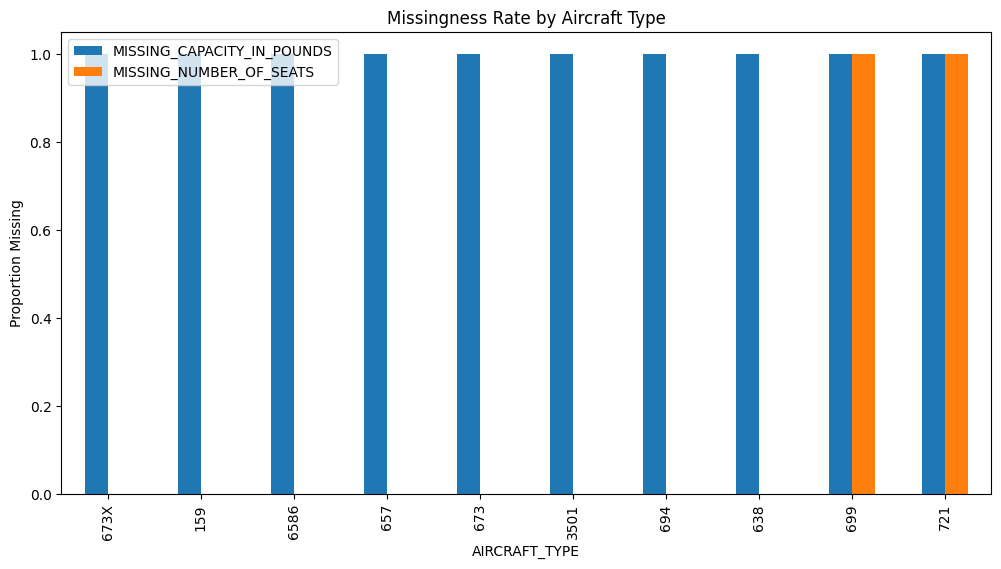

In [613]:
import matplotlib.pyplot as plt
aircraft_missing[:10].plot(kind="bar", figsize=(12,6))
plt.title("Missingness Rate by Aircraft Type")
plt.ylabel("Proportion Missing")
plt.xticks(rotation=90)
plt.show()

Category of missingness for both columns seems to be missing at random, as it seems to be correlated with the aircraft type and with each other but no other correlation. For both columns, there are 324 aircraft types that are missing some percentage of their rows. 

An imputation method that could be used is constant fill with the mean value of a capacity of a similar aircraft. Alteratively the capacity and seats could just be Googled and a constant fill could be used with a value is found online, but that would be difficult.

## 2. Inspect columns MANUFACTURER, MODEL, AIRCRAFT_STATUS, OPERATING_STATUS and standardize/transform if necessary

In [614]:
# find missing
#673X, 159, 6586, 657, 673, 3501, 694, 638, 699, 721
# print manufacturers for these models
print(inventory[inventory['AIRCRAFT_TYPE'].isin(['673X', '159', '6586', '657', '673', '3501', '694', '638', '699', '721'])][['AIRCRAFT_TYPE', 'MODEL', 'MANUFACTURER']].drop_duplicates())
'''
Manfucaturer Model
Embraer ERJ170-200LR
TheBoeingCompany B737-MAX800ALLPAX
Bombardier BD-700-1A10Global650
Bombardier CRJ-700
Embraer ERJ-175
CESSNA CESSNAT-210N
Airbus 320-214
Bombardier CRJ-900
Airbus 321-211
Airbus 321-271NX
'''

       AIRCRAFT_TYPE                 MODEL      MANUFACTURER
119603           694               320-214            Airbus
119614           699               321-211            Airbus
119720           721             321-271NX            Airbus
120431          6586  BD-700-1A10Global650        Bombardier
121386           657               CRJ-700        Bombardier
121660           638               CRJ-900        Bombardier
121683           673               ERJ-175           Embraer
122077          673X    ERJ170-200LRALLPAX           Embraer
122110          3501          CESSNAT-210N            CESSNA
126075           159     B737-MAX800ALLPAX  TheBoeingCompany
128277          6586           BD-700-1A10        Bombardier
129944          673X          ERJ170-200LR           Embraer
129985          3501                 T210N            CESSNA


'\nManfucaturer Model\nEmbraer ERJ170-200LR\nTheBoeingCompany B737-MAX800ALLPAX\nBombardier BD-700-1A10Global650\nBombardier CRJ-700\nEmbraer ERJ-175\nCESSNA CESSNAT-210N\nAirbus 320-214\nBombardier CRJ-900\nAirbus 321-211\nAirbus 321-271NX\n'

In [421]:
# look for similar models w similar capacities:
# look at all embraer models that contain erj in the model name
embraer_erj_models = inventory[(inventory['MANUFACTURER'] == 'Embraer') & (inventory['MODEL'].str.contains('ERJ-175'))][['MODEL', 'CAPACITY_IN_POUNDS', 'AIRCRAFT_TYPE']].dropna().drop_duplicates()
print(embraer_erj_models)

                MODEL  CAPACITY_IN_POUNDS AIRCRAFT_TYPE
55234   ERJ-175-100LR             85517.0          6731
55246   ERJ-175-200LR             85517.0          6731
57085   ERJ-175-100SU             85517.0          6731
68823         ERJ-175             12775.0          6731
83042         ERJ-175                 0.0          6731
105139        ERJ-175                 0.0          6731
105874        ERJ-175             84500.0          6731


Seems like there are some entries with the same model name. In this case, it looks like a "1" was ommited from the aircraft type column, as the original column's value was 673.

Now check if this is the case for other models with missing capacities.

In [444]:
# investigate columns with missing capacity in pounds values - see if there are same manufacturers/models
total_count = 0
more_count = 0
for model,manu,atype in inventory[inventory['MISSING_CAPACITY_IN_POUNDS'] != 0.0][['MODEL', 'MANUFACTURER', 'AIRCRAFT_TYPE']].drop_duplicates().values:
    total_count += 1
    #print(f"Model: {model}")
    more = inventory[(inventory['MODEL'] == model) & (inventory['MANUFACTURER'] == manu) & (inventory['AIRCRAFT_TYPE'] == atype)][['MODEL', 'MANUFACTURER', 'AIRCRAFT_TYPE']].drop_duplicates()
    if more.shape[0] > 0:  # not empty df
        #print(more)
        more_count += 1
print(more_count, total_count)

539 539


In [447]:
# do the same for missing number of seats
total_count = 0
more_count = 0
for model,manu,atype in inventory[inventory['MISSING_NUMBER_OF_SEATS'] != 0.0][['MODEL', 'MANUFACTURER', 'AIRCRAFT_TYPE']].drop_duplicates().values:
    total_count += 1
    #print(f"Model: {model}")
    more = inventory[(inventory['MODEL'] == model) & (inventory['MANUFACTURER'] == manu) & (inventory['AIRCRAFT_TYPE'] == atype)][['MODEL', 'MANUFACTURER', 'AIRCRAFT_TYPE']].drop_duplicates()
    if more.shape[0] > 0:  # not empty df
        #print(more)
        more_count += 1
    else:
        print(f"Model with missing number of seats but no other entries: {model}, {manu}, {atype}")
print(more_count, total_count)

Model with missing number of seats but no other entries: b7673, boeing, nan
Model with missing number of seats but no other entries: a3006, airbus, nan
Model with missing number of seats but no other entries: b7772, boeing, nan
Model with missing number of seats but no other entries: b7674, boeing, nan
Model with missing number of seats but no other entries: b7573, boeing, nan
Model with missing number of seats but no other entries: b7672, boeing, nan
Model with missing number of seats but no other entries: b7572, boeing, nan
Model with missing number of seats but no other entries: a321, airbus, nan
Model with missing number of seats but no other entries: dc103, mcdonnelldouglas, nan
Model with missing number of seats but no other entries: b7472/3, boeing, nan
Model with missing number of seats but no other entries: b7471, boeing, nan
Model with missing number of seats but no other entries: b7474, boeing, nan
Model with missing number of seats but no other entries: a3303, airbus, nan
M

This shows that we can impute the missing capacity with other entries with the same manufacturer, model, and aircraft type.

For missing number of seats, it seems more complicated. A lot of it seems like it has to do with standardization. For example, some models have a ton of whitespace after the model, and manufacturers aren't standard, with diffferences like BOEING vs THEBOEINGCOMPANY and AIRBUS vs AIRBUSINDUSTRIES. I'll continue this imputation after step 2!

In [439]:
# impute columns with missing capacity in pounds values with mode capacity from same manufacturers/models
def impute_capacity_in_pounds(df):
    df['CAPACITY_IN_POUNDS'] = df["CAPACITY_IN_POUNDS"].fillna(
        df.groupby(["MODEL", "MANUFACTURER"])["CAPACITY_IN_POUNDS"].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else x)
    )
    return df
inventory = impute_capacity_in_pounds(inventory)

In [424]:
# look at existing and missing airline id values
existing_airline_id = inventory[inventory['AIRLINE_ID'].notnull()]
missing_airline_id = inventory[inventory['AIRLINE_ID'].isnull()]

print("Existing Airline IDs:")
print(existing_airline_id[['CARRIER', 'CARRIER_NAME', 'AIRLINE_ID']].drop_duplicates().sort_values('AIRLINE_ID').head(20))

print("\nMissing Airline IDs:")
print(missing_airline_id[['CARRIER', 'CARRIER_NAME', 'UNIQUE_CARRIER_NAME']].drop_duplicates())

Existing Airline IDs:
      CARRIER                 CARRIER_NAME  AIRLINE_ID
4440       NW      Northwest Airlines Inc.     19386.0
26249     NW       Northwest Airlines Inc.     19386.0
28071     WN        Southwest Airlines Co.     19393.0
6319       WN       Southwest Airlines Co.     19393.0
23527     AQ               Aloha Air Cargo     19678.0
16363      AQ              Aloha Air Cargo     19678.0
1325       AQ          Aloha Airlines Inc.     19678.0
5392       QX                  Horizon Air     19687.0
27045     QX                   Horizon Air     19687.0
3888       HA       Hawaiian Airlines Inc.     19690.0
25824     HA        Hawaiian Airlines Inc.     19690.0
1635       CO   Continental Air Lines Inc.     19704.0
23796     CO    Continental Air Lines Inc.     19704.0
24194     DL          Delta Air Lines Inc.     19790.0
2295       DL         Delta Air Lines Inc.     19790.0
22789     AA        American Airlines Inc.     19805.0
525        AA       American Airlines Inc. 

In [425]:
# see if any L4 and OH entries have airline ids
print(inventory[(inventory['CARRIER'].isin(['L4', 'OH'])) & (inventory['AIRLINE_ID'].notnull())][['CARRIER', 'CARRIER_NAME', 'AIRLINE_ID']].drop_duplicates())

      CARRIER                           CARRIER_NAME  AIRLINE_ID
4896       OH                            Comair Inc.     20417.0
18739      L4  Lynx Aviation d/b/a Frontier Airlines     21217.0
68915      OH                      PSA Airlines Inc.     20397.0


In [426]:
# impute OH with 20397 and L4 with 21217
def impute(carrier, airline_id):
    inventory.loc[(inventory['CARRIER'] == carrier) & (inventory['AIRLINE_ID'].isnull()), 'AIRLINE_ID'] = airline_id
impute('OH', 20397)
impute('L4', 21217)

In [427]:
# check imputation results
print(inventory[(inventory['CARRIER'].isin(['L4', 'OH'])) & (inventory['AIRLINE_ID'].notnull())][['CARRIER', 'CARRIER_NAME', 'AIRLINE_ID']].drop_duplicates())

      CARRIER                           CARRIER_NAME  AIRLINE_ID
4896       OH                            Comair Inc.     20417.0
11465      L4  Lynx Aviation d/b/a Frontier Airlines     21217.0
54610      OH                            Comair Inc.     20397.0
68915      OH                      PSA Airlines Inc.     20397.0


### Inspect the columns MANUFACTURER, MODEL, AIRCRAFT_STATUS, and OPERATING_STATUS. 
### Decide, for each column, if transformation or standardization of data are required. 
### Give your reasoning and code if you decide to transform the data.

In [428]:
# Inspect the columns MANUFACTURER, MODEL, AIRCRAFT_STATUS, and OPERATING_STATUS. 

# print unique values in these columns
print(inventory['MANUFACTURER'].unique())
print(inventory['MODEL'].unique()) 
print(inventory['AIRCRAFT_STATUS'].unique())
print(inventory['OPERATING_STATUS'].unique())

['CANADAIR' 'CURTISS' 'MCDONNELL-DOUGLAS' 'PIPER' 'CESSNA' 'EMBRAER'
 'BOEING' 'AIRBUS' 'FOKKER' 'ATR' 'BELL' 'FAIRCHILD' 'CONVAIR' 'LOCKHEED'
 'SAAB AIRCRAFT' 'BAE' 'BOMBARDIER' 'DEHAVILLAND' 'DASSULT SUD'
 'BEECHCRAFT'
 'BOEING                                                                          '
 'DORNIER                                                                         '
 'IAI                                                                             '
 'GULFSTREAM                                                                      '
 'BOMBARDIER                                                                      '
 'RAYTHEON                                                                        '
 'CESSNA                                                                          '
 'CANADAIR                                                                        '
 'CURTISS                                                                         '
 'MCDONNELL-DOUGLAS    

Above shows that:

For MANUFACTURER, standardization is required. For some reason, there are values with a ton of whitespace attached at the end (e.g. 'BOEING' vs 'BOEING      ')

For AIRCRAFT_STATUS, standardizations is required for casing.

For OPERATING_STATUS, there's a casing issue, but also some entries are blank.

The MODEL column needs additional inspection

In [429]:
print(inventory['MODEL'].unique().shape) # shows that the model column is really large


(1341,)


In [430]:
# print values that include boeing for model column
def print_col_specific(df, column, keyword):
    mask = df[column].str.lower().str.contains(keyword, na=False)
    print(df.loc[mask, column].unique())
print_col_specific(inventory, "MODEL", "boeing")
# shows inconsistencies in casing only it seems

['BOEING717-200' 'BOEING737-700/LR' 'BoeingB767-319ERPAX'
 'BoeingB767-300ERPAX' 'BoeingB767-33AERPAX' 'BoeingB767-324ERPAX'
 'BoeingB777-222ERPAX' 'BoeingB767-36NERPAX' 'BoeingB767-224ERPAX'
 'BoeingB767-3Q8ERPAX' 'BoeingB767-316ERPAX' 'BoeingB767-323ERPAX'
 'BoeingB-737-7HJ' 'BoeingB-737-7BD' 'BoeingB-737-76N' 'BOEING767-200/ER'
 'BOEING767-300/ER' 'BOEING757-200' 'Boeing737-45D' 'Boeing717-2BD'
 'Boeing717-23S' 'Boeing737-4K5' 'Boeing737-883']


In [431]:
print_col_specific(inventory, "MODEL", "crj") 
# shows inconsistencies like CRJ-900 vs CRJ900

['CRJ-2/4' 'CRJ-900' 'CRJ200' 'CRJ700' 'CRJ900' 'CRJ-200' 'CRJ-400'
 'CRJ-700' 'CRJ70C' 'CRJ-700Passenger' 'CRJ100-Passanger'
 'CRJ200-Passanger' 'CRJ700-Passanger' 'CRJ900-Passanger' 'CRJ-701'
 'CRJ200-2B19' 'CRJ700-2C10' 'CRJ900-2D24' 'CRJ-200-PSGR' 'CRJ-700-PSGR'
 'CRJ-900-PSGR' 'CRJ100-PSGR' 'CRJ-900LR-PSGR' 'CRJ-100LR-PSGR'
 'CRJ-200LR-PSGR' 'CRJ-70C' 'CRJ-200-2B19' 'CRJ-700-2C10' 'CRJ-900-2D24'
 'CRJ90C' 'CRJ701' 'CRJ200-2B10' 'CRJ900-2D10' 'CRJ-700LR-PSGR'
 'CRJ-200/440' 'CRJ550' 'CRJ-550-PSGR' 'CRJ200LR']


In [432]:
print_col_specific(inventory, "MANUFACTURER", "airbus")
# shows a ton of inconsistencies in the manufacturer column for airbus,
# with different casings and also some extra info like Industrie(s) or Company

['AIRBUS'
 'AIRBUS                                                                          '
 'Airbus' 'AIRBUSINDUSTRIES' 'AirbusIndustrie' 'AirbusIndustries' 'airbus'
 'AirbusCompany' 'AirBlue/Airbus']


In [443]:
# standardize and strip whitespace
def standardize_manufacturer(name):
    name = name.lower()
    manufacturer_dict = {
        "airbus": "airbus",
        "boeing": "boeing",
        "embraer": "embraer",
        "bombardier": "bombardier",
        "cessna": "cessna",
        "mcdon": "mcdonnelldouglas",
        'douglas':"mcdonnelldouglas",
        "learjet": "learjet",
        "gulfstream": "gulfstream",
        "saab": 'saab',
        'raetheon': 'raytheon',
        'gecas':'gecommercialaviationservices',
        'ge':'gecommercialaviationservices',
        'lear':'learjet',
        'dassault':'dassault',
        'israel':'iai',
        'fokker':'fokker'
    }
    for k,v in manufacturer_dict.items():
        if k in name:
            return v

    else:
        return name.strip().lower()

def standardize_model(model):
    if type(model) != str:
        return model
    model = model.lower().replace(" ", "").replace("-", "")
    model = model.replace("passanger", "").replace("psgr", "").replace("passenger", "")
    
    return model

inventory['MANUFACTURER'] = inventory['MANUFACTURER'].apply(standardize_manufacturer)
inventory['MODEL'] = inventory['MODEL'].apply(standardize_model)

In [434]:
print_col_specific(inventory, "MANUFACTURER", "")
print(inventory['MANUFACTURER'].value_counts())
print(inventory['MODEL'].drop_duplicates().shape)

['canadair' 'curtiss' 'mcdonnelldouglas' 'piper' 'cessna' 'embraer'
 'boeing' 'airbus' 'fokker' 'atr' 'bell' 'fairchild' 'convair' 'lockheed'
 'saab' 'bae' 'bombardier' 'dehavilland' 'dassult sud' 'beechcraft'
 'dornier' 'iai' 'gulfstream' 'raytheon' 'gecommercialaviationservices'
 'hawker' 'learjet' 'globalexp' 'dassault' 'pilatus' 'beechhawker400xp'
 'aero/aeri' 'ama/expr' 'continental-tsio-520r' 'cssnacitationx'
 'rolls-royce' 'casa' 'aerospatiale' 'cfminternational' 'b757-223' 'alc'
 'aercap' 'jacksonsquare' 'avolon' 'icbc' 'goal' 'mcdo' 'sikorsky'
 'agustawestland' 'calc' 'philippineairlines' 'vueling/aercap'
 'iberia/smbc' 'iberia/ilfc' 'cebupacific/smbc' 'cebupacific'
 'kuban/oakhill' 'easyjet/goal' 'frontier/aercap' 'avianca/acg'
 'easyjet/fuyo' 'cobalt/icbc' 'easyjet/investec' 'iberia/mcap'
 'alitalia/realis' 'saudia/alafco' 'cebupacific/jplease' 'iailtd'
 'jplease/aerlingus' 'cba/easyjet' 'jplease/cebupacific'
 'smbcaviationcapitallimited' 'easyjet/bbam' 'smbc/sky' 'aercap/fr

In [435]:
def standardize_aircraft_status(status):
    if type(status) != str:
        return status
    return status.lower().strip()
inventory["AIRCRAFT_STATUS"] = inventory["AIRCRAFT_STATUS"].apply(standardize_aircraft_status)
print_col_specific(inventory, "AIRCRAFT_STATUS", "")

['b' 'o' 'a' 'l']


In [436]:
def standardize_operating_status(status):
    if type(status) != str:
        return status
    if status.lower() not in ['y', 'n']:
        return "n"
    return status.lower().strip()

inventory["OPERATING_STATUS"] = inventory["OPERATING_STATUS"].apply(standardize_operating_status)
print_col_specific(inventory, "OPERATING_STATUS", "")

['y' 'n']


In [ ]:
# now we can also try to impute missing number of seats
# impute columns with missing capacity in pounds values with mode capacity from same manufacturers/models
def impute_num_seats(df):
    df['NUMBER_OF_SEATS'] = df["NUMBER_OF_SEATS"].fillna(
        df.groupby(["MODEL", "MANUFACTURER"])["NUMBER_OF_SEATS"].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else x)
    )
    return df
inventory = impute_num_seats(inventory)

## 3. Remove data rows that still have missing values. Report the amount of remaining data you obtained.

In [449]:
print('data before dropping rows with missing values:', inventory.shape[0])
# print number of missing values in each column
print(inventory.isnull().sum())

data before dropping rows with missing values: 132313
YEAR                              0
CARRIER                           0
CARRIER_NAME                      0
MANUFACTURE_YEAR                  0
UNIQUE_CARRIER_NAME               0
SERIAL_NUMBER                     0
TAIL_NUMBER                       0
AIRCRAFT_STATUS                   0
OPERATING_STATUS                  0
NUMBER_OF_SEATS                7099
MANUFACTURER                      0
AIRCRAFT_TYPE                 29933
MODEL                            11
CAPACITY_IN_POUNDS             5385
ACQUISITION_DATE                967
AIRLINE_ID                        0
UNIQUE_CARRIER                  164
MISSING_CAPACITY_IN_POUNDS        0
MISSING_NUMBER_OF_SEATS           0
dtype: int64


In [510]:
# drop rows with any missing values or zeroes in number of seats or capacity in pounds
cleaned_inventory = inventory.dropna()
cleaned_inventory = cleaned_inventory[(cleaned_inventory['NUMBER_OF_SEATS'] != 0.0) & (cleaned_inventory['CAPACITY_IN_POUNDS'] != 0.0)]

print(f"remaining data after dropping rows with missing values: {cleaned_inventory.shape[0]} rows")

remaining data after dropping rows with missing values: 70931 rows


Quite a huge drop - we're basically cutting 30% of our data. However, the row that's missing the most is AIRCRAFT_TYPE, and that's probably near impossible to impute. Maybe we could have done so with seats and capacity that had values in the row before we imputed them, since they're probably related to aircraft size.

There's also likely more that could be done to standardize aircraft type, although it seems incredibly messy and has a pretty big impact if you get it wrong. For example: CRJ-2/4 and CRJ-200/440 are apparently the same label, but represent two different types of aircraft.

## 4. Transformation and derivative variables

For the columns NUMBER_OF_SEATS and CAPACITY_IN_POUNDS, check the skewness in the variable and plot a histogram for each variable.

Skewness of NUMBER_OF_SEATS: -0.4607529092235389
Skewness of CAPACITY_IN_POUNDS: 2.529953302353802


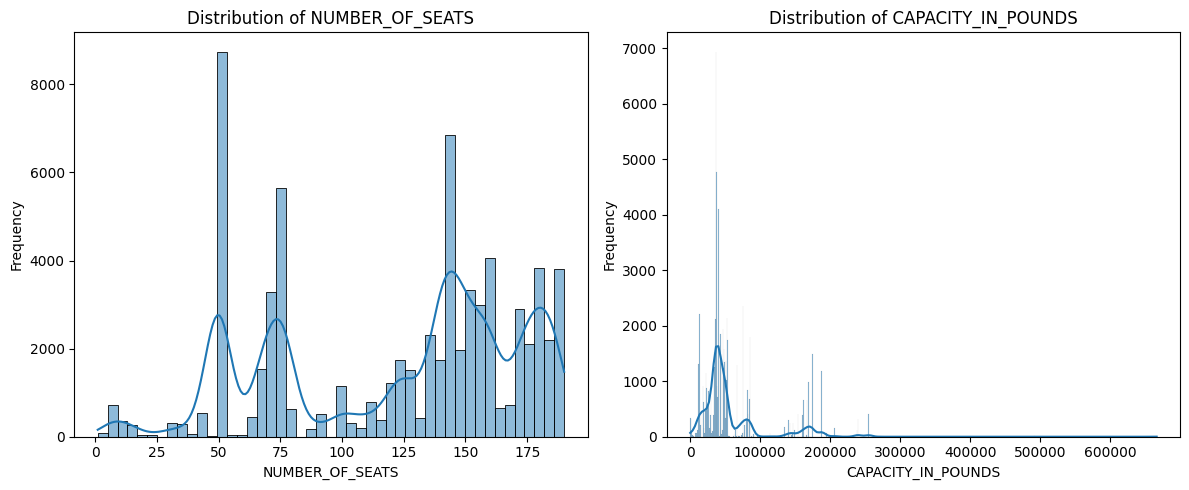

In [511]:
# For the columns NUMBER_OF_SEATS and CAPACITY_IN_POUNDS, check the skewness in the variable and plot a histogram for each variable.
import seaborn as sns
import matplotlib.pyplot as plt

# Check skewness and drop zero values
print("Skewness of NUMBER_OF_SEATS:", cleaned_inventory['NUMBER_OF_SEATS'].skew())
print("Skewness of CAPACITY_IN_POUNDS:", cleaned_inventory['CAPACITY_IN_POUNDS'].dropna().skew())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(cleaned_inventory['NUMBER_OF_SEATS'], kde=True)
plt.title('Distribution of NUMBER_OF_SEATS')
plt.xlabel('NUMBER_OF_SEATS')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(cleaned_inventory['CAPACITY_IN_POUNDS'], kde=True)
plt.title('Distribution of CAPACITY_IN_POUNDS')
plt.xlabel('CAPACITY_IN_POUNDS')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [512]:
# print mode of cleaned number of seats and capacity in pounds
print("mode of NUMBER_OF_SEATS:", cleaned_inventory['NUMBER_OF_SEATS'].mode()[0])
print("max of CAPACITY_IN_POUNDS:", cleaned_inventory['CAPACITY_IN_POUNDS'].max())

mode of NUMBER_OF_SEATS: 50.0
max of CAPACITY_IN_POUNDS: 665998.0


In [526]:
from scipy.stats import boxcox

cleaned_inventory['NUMBER_OF_SEATS_boxcox'], _ = boxcox(cleaned_inventory[cleaned_inventory['NUMBER_OF_SEATS'] != 0.0]['NUMBER_OF_SEATS'])
cleaned_inventory['CAPACITY_IN_POUNDS_boxcox'], _ = boxcox(cleaned_inventory[cleaned_inventory['CAPACITY_IN_POUNDS'] != 0.0]['CAPACITY_IN_POUNDS'])

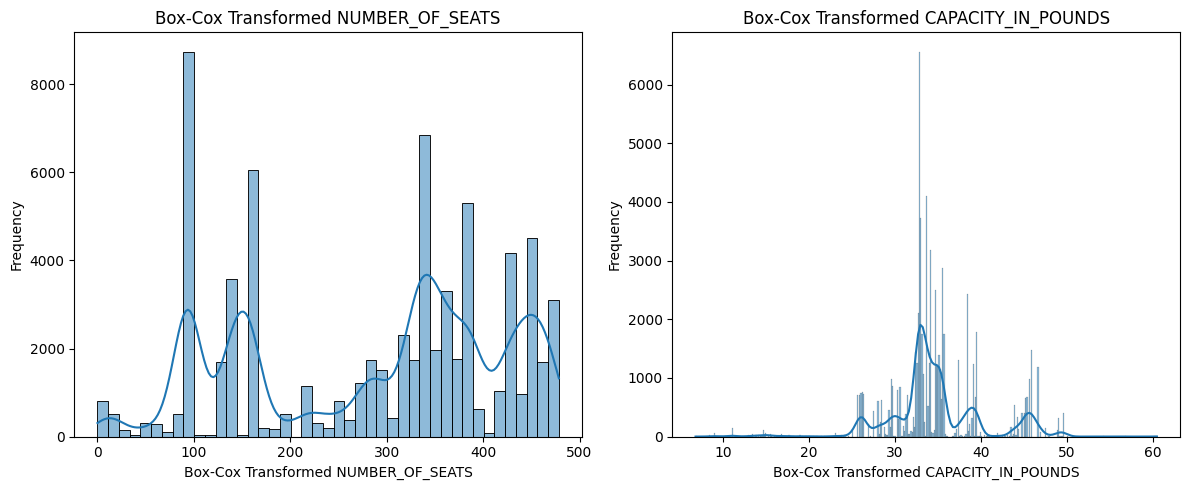

In [527]:
# plot histogram for boxcox transformed variables
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(cleaned_inventory['NUMBER_OF_SEATS_boxcox'], kde=True)
plt.title('Box-Cox Transformed NUMBER_OF_SEATS')
plt.xlabel('Box-Cox Transformed NUMBER_OF_SEATS')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(cleaned_inventory['CAPACITY_IN_POUNDS_boxcox'], kde=True)
plt.title('Box-Cox Transformed CAPACITY_IN_POUNDS')
plt.xlabel('Box-Cox Transformed CAPACITY_IN_POUNDS')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

After the Box-Cox transformation, I don't really notice huge differences in the distribution of the values on the graph (the curves look VERY similar), but I do notice huge changes in the scales of the X-axes. The maximum value of the number of seats goes from ~175 to ~500, and the maximum value of capacity (lbs) goes from near 700,000 to 60. I could understand the latter, if it thinks that 600,000 is an unreasonably large number to have on a graph and thinks the scale should be in 10,000lbs. However, I'm not really sure about the number of seats scale conversion.

## 5. Feature Engineering

In [528]:
'''
Create a new column SIZE by the quartiles of NUMBER_OF_SEATS
below 25% percentile: SMALL
25% - 50% percentile: MEDIUM
50% - 75% percentile: LARGE
above 75% percentile: XLARGE
'''
cleaned_inventory['SIZE'] = pd.qcut(cleaned_inventory['NUMBER_OF_SEATS'], q=4, labels=['SMALL', 'MEDIUM', 'LARGE', 'XLARGE'])

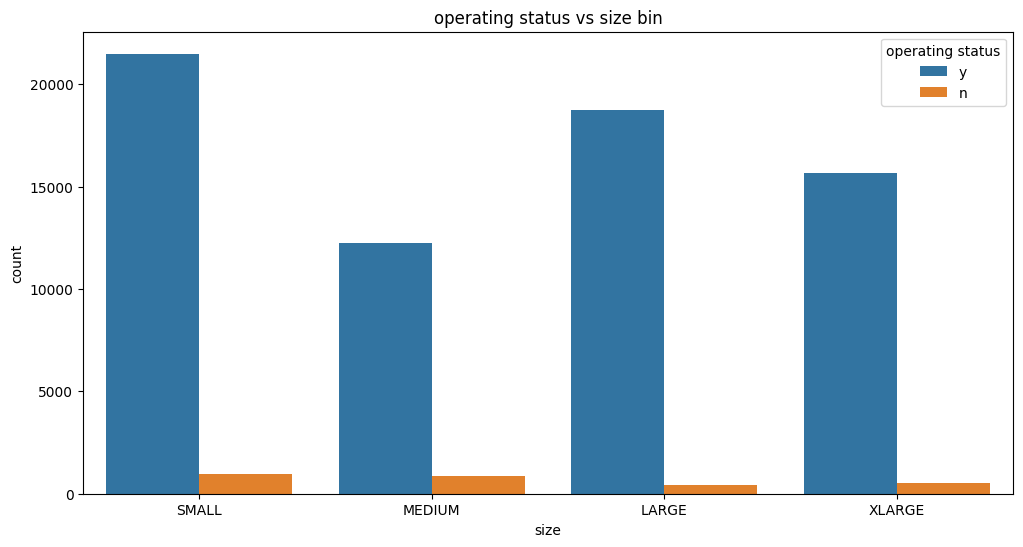

In [529]:
plt.figure(figsize=(12, 6))
sns.countplot(data=cleaned_inventory, x='SIZE', hue='OPERATING_STATUS')
plt.title('operating status vs size bin')
plt.xlabel('size')
plt.ylabel('count')
plt.legend(title='operating status')
plt.show()

Clearly, aircrafts are operating way more than they aren’t. It would be difficult for airlines to make money if the opposite was true. Something interesting I noticed is the count for small airplanes is the highest, then large airplanes is next, the X-large, then medium. This could be due to the size of the bins, but also could be because medium aircrafts provide a middle ground that may not be needed as much? Smaller airplanes may be sufficient for short, domestic flights, and large/X-large planes may be useful for longer international flights, potentially making medium planes less useful.

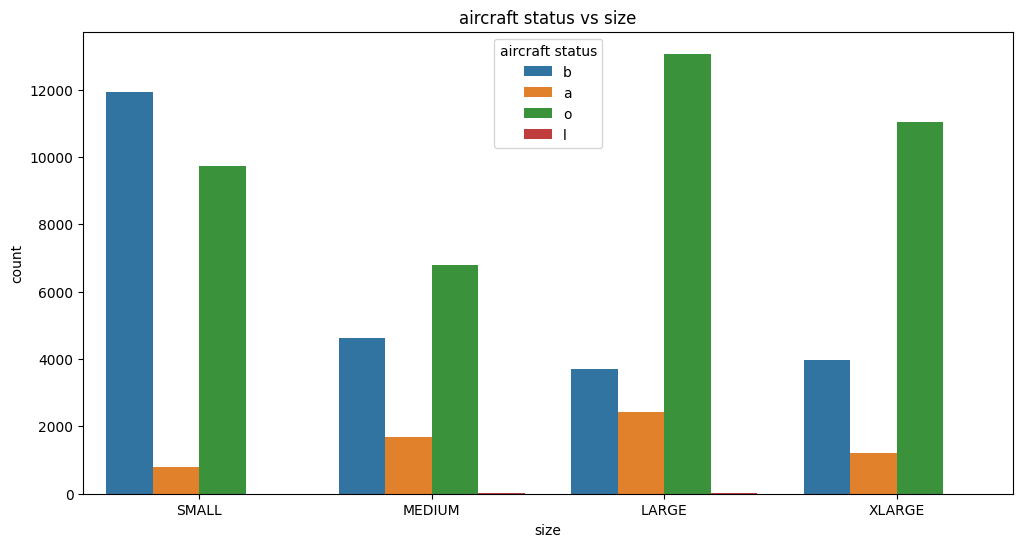

In [530]:
plt.figure(figsize=(12, 6))
sns.countplot(data=cleaned_inventory, x='SIZE', hue='AIRCRAFT_STATUS')
plt.title('aircraft status vs size')
plt.xlabel('size')
plt.ylabel('count')
plt.legend(title='aircraft status')
plt.show()

The second graph is harder to interpret, because we aren’t given what the letters stand for. L makes up a tiny portion of the graph, and is practically nonexistent, especially for small and X-large. Status B makes up the majority of small aircrafts, but a lot smaller proportion for other sizes. Status O makes up the vast majority of the proportion of all of the other aircraft size groups, maybe indicating it means “operational” or some equivalent of “working”. Lastly, A makes up a small, but notable, percentage of each size class.


## 6. Modeling Refresher

In [540]:
# think of variables that would affect each prediction the most
print(cleaned_inventory.columns)

Index(['YEAR', 'CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR',
       'UNIQUE_CARRIER_NAME', 'SERIAL_NUMBER', 'TAIL_NUMBER',
       'AIRCRAFT_STATUS', 'OPERATING_STATUS', 'NUMBER_OF_SEATS',
       'MANUFACTURER', 'AIRCRAFT_TYPE', 'MODEL', 'CAPACITY_IN_POUNDS',
       'ACQUISITION_DATE', 'AIRLINE_ID', 'UNIQUE_CARRIER',
       'MISSING_CAPACITY_IN_POUNDS', 'MISSING_NUMBER_OF_SEATS',
       'NUMBER_OF_SEATS_boxcox', 'CAPACITYx_IN_POUNDS_boxcox',
       'CAPACITY_IN_POUNDS_boxcox', 'SIZE'],
      dtype='object')


In [556]:
num_seat_predictors = ['CAPACITY_IN_POUNDS', 'YEAR', 'AIRLINE_ID']
cap_lbs_predictors = ['NUMBER_OF_SEATS', 'YEAR', 'AIRLINE_ID'] # prob similar

In [557]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import math

X_num_seats = cleaned_inventory[num_seat_predictors]
y_num_seats = cleaned_inventory['NUMBER_OF_SEATS']
X_capacity = cleaned_inventory[cap_lbs_predictors]
y_capacity = cleaned_inventory['CAPACITY_IN_POUNDS']

# split train test with 80-20 split
x_train_data_seats, x_test_data_seats, y_train_data_seats, y_test_data_seats = train_test_split(
    X_num_seats, y_num_seats, test_size=0.2, random_state=42
)
x_train_data_capacity, x_test_data_capacity, y_train_data_capacity, y_test_data_capacity = train_test_split(
    X_capacity, y_capacity, test_size=0.2, random_state=42
)

In [558]:
# Lr for NUMBER_OF_SEATS
# train
lr_num_seats = LinearRegression()
lr_num_seats.fit(x_train_data_seats, y_train_data_seats)

# predict
train_pred = lr_num_seats.predict(x_train_data_seats)
test_pred = lr_num_seats.predict(x_test_data_seats)

seats_lr_train_rmse = math.sqrt(root_mean_squared_error(y_train_data_seats, train_pred))
seats_lr_test_rmse = math.sqrt(root_mean_squared_error(y_test_data_seats, test_pred))

print(f"Train RMSE: {seats_lr_train_rmse}")
print(f"Test RMSE: {seats_lr_test_rmse}")

Train RMSE: 6.3668882767755095
Test RMSE: 6.379206676676486


In [559]:
# Lr for CAPACITY_IN_POUNDS
# train
lr_cap_lbs = LinearRegression()
lr_cap_lbs.fit(x_train_data_capacity, y_train_data_capacity)

# predict
train_pred = lr_cap_lbs.predict(x_train_data_capacity)
test_pred = lr_cap_lbs.predict(x_test_data_capacity)

cap_lr_train_rmse = math.sqrt(root_mean_squared_error(y_train_data_capacity, train_pred))
cap_lr_test_rmse = math.sqrt(root_mean_squared_error(y_test_data_capacity, test_pred))

print(f"Train RMSE: {cap_lr_train_rmse}")
print(f"Test RMSE: {cap_lr_test_rmse}")

Train RMSE: 216.34572935415332
Test RMSE: 217.19294081640984


In [560]:
# rf for NUMBER_OF_SEATS
# train
rf_num_seats = RandomForestRegressor(n_estimators=100, random_state=42)
rf_num_seats.fit(x_train_data_seats, y_train_data_seats)

# predict
train_pred = rf_num_seats.predict(x_train_data_seats)
test_pred = rf_num_seats.predict(x_test_data_seats)

seats_rf_train_rmse = math.sqrt(root_mean_squared_error(y_train_data_seats, train_pred))
seats_rf_test_rmse = math.sqrt(root_mean_squared_error(y_test_data_seats, test_pred))

print(f"Train RMSE: {seats_rf_train_rmse}")
print(f"Test RMSE: {seats_rf_test_rmse}")

Train RMSE: 2.2201288923786375
Test RMSE: 2.3436664841426342


In [561]:
# rf for CAPACITY_IN_POUNDS
# train
rf_cap_lbs = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cap_lbs.fit(x_train_data_capacity, y_train_data_capacity)

# predict
train_pred = rf_cap_lbs.predict(x_train_data_capacity)
test_pred = rf_cap_lbs.predict(x_test_data_capacity)

cap_rf_train_rmse = math.sqrt(root_mean_squared_error(y_train_data_capacity, train_pred))
cap_rf_test_rmse = math.sqrt(root_mean_squared_error(y_test_data_capacity, test_pred))

print(f"Train RMSE: {cap_rf_train_rmse}")
print(f"Test RMSE: {cap_rf_test_rmse}")

Train RMSE: 63.160827075048196
Test RMSE: 68.55471749128911


From these RMSE values, it's clear that the problem is highly predictable. I think the best predictors are definitely seats and capacity for each other, because they both are highly correlated with the size of the aircraft. I'm not sure if year had much of an impact at all.  

One thing I would be interested in looking at is certain numbers in the model of the aircraft. For example, from looking at data previously, I saw that there's CRJ200 and CRJ900, and after some quick research, I found that the number after the planes' AIRCRAFT_TYPE column roughly correlates to size (except for CRJ200 and CRJ440).

It's also clear that the random forest regressor performs better than the linear regressor, but the former slightly overfits leading to larger test RMSE values. However, the RMSE is generally way lower than the linear regressor's RMSE.